# Sprint 3 – Hiperparametrización y Modelo Final
## Grupo 10 | Forecast de Ingresos Mensuales – Olist E-Commerce

**Objetivo:** optimizar el modelo, evaluar el rendimiento final comparando candidatos y exportar el artefacto (.pkl) para uso mensual.

**Actividades cubiertas (adaptando el flujo de trabajo de ejemplo a series temporales):**

1. Selección de variables con **salida trazable por variable** (tabla con `flagSelected` + importancias, exportada a CSV) y **costo de la selección** (equivalente al "60 → 30 features: Gini 50 → 47" del ejemplo)
2. Hiperparametrización con **Optuna** + validación cruzada temporal (`TimeSeriesSplit`)
3. Comparación de los modelos del ejemplo — **Random Forest, Regresión (Ridge), XGBoost** — más LightGBM, Prophet, SARIMA y baselines, todos bajo el mismo backtest
4. **Gap train vs backtest** por modelo (equivalente a "reducir la distancia entre AUC train y AUC backtest")
5. Exportación del modelo final en **pickle** (`final_model.pkl`) con metadata de trazabilidad (equivalente a `final_model.__dict__`)
6. Documentación del pipeline de retraining mensual

> Este notebook consume los artefactos del Sprint 2 (`data/processed/monthly_features.parquet` y los módulos de `src/`).

In [1]:
# ── Setup: ajustar ruta al proyecto
import sys, os
PROJECT_ROOT = '..'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from src.utils.helpers import load_config, setup_logger
setup_logger('sprint3.log')

cfg     = load_config()
target  = cfg['project']['target']
horizon = cfg['project']['horizon_months']

import sklearn, lightgbm, optuna, xgboost
print('✅ Setup completado')
print(f"   Proyecto : {cfg['project']['name']} v{cfg['project']['version']}")
print(f"   Target   : {target} | Horizonte: {horizon} meses")
print(f"   Versiones: sklearn {sklearn.__version__} | lightgbm {lightgbm.__version__} | "
      f"xgboost {xgboost.__version__} | optuna {optuna.__version__}")

✅ Setup completado
   Proyecto : olist_revenue_forecast v1.0.0
   Target   : monthly_revenue | Horizonte: 3 meses
   Versiones: sklearn 1.9.0 | lightgbm 4.6.0 | xgboost 3.2.0 | optuna 4.9.0


## Paso 1 – Datos, limpieza y selección de variables (heredados del Sprint 2)

Se reutiliza el flujo del Sprint 2: tabla mensual → limpieza (clip + NaN + agrupamiento + escalado) → splits temporales → selección de variables (Missing → PSI → Correlación → Univariante → Wrapper RFECV).

> **Nota metodológica (WoE/IV):** el flujo de ejemplo menciona WoE/IV como técnica de selección supervisada. WoE/IV está definida para **targets binarios** (clasificación, p. ej. churn/scoring). Como nuestro target `monthly_revenue` es **continuo** (regresión / serie temporal), se sustituye por su equivalente para regresión: selección **univariante** por información mutua / F-test, manteniendo el mismo rol dentro del flujo (filter supervisado).

In [2]:
from src.features.cleaning import clean_monthly_table
from src.data.monthly_agg import split_data
from src.features.selection import run_feature_selection, get_selection_summary
from src.utils.helpers import load_dataframe

# Tabla mensual generada en el Sprint 2
monthly = load_dataframe('monthly_features')
monthly['ds'] = pd.to_datetime(monthly['ds'])
monthly['year_month'] = monthly['ds'].dt.to_period('M')
print(f"Tabla mensual: {monthly.shape[0]} meses x {monthly.shape[1]} cols "
      f"({monthly['ds'].min():%b %Y} → {monthly['ds'].max():%b %Y})")

# Limpieza (mismo pipeline del Sprint 2, re-ajustado sobre los datos)
monthly_clean, cleaning_pipeline = clean_monthly_table(monthly, cfg, fit=True)

# Splits temporales (según flujo Excel)
splits    = split_data(monthly_clean, cfg)
train     = splits['train']
val       = splits['val']
all_data  = splits['all']
test_data = splits['backtest'] if len(splits['backtest']) > 0 else val
n_test    = min(horizon, len(test_data))
y_test    = test_data[target].values[:n_test]
print(f"\nEvaluación final sobre: {test_data['ds'].min():%b %Y} → {test_data['ds'].max():%b %Y} "
      f"({len(test_data)} meses)")

# Selección de variables (flujo completo del Sprint 2)
selection_result  = run_feature_selection(
    monthly_train=train,
    monthly_val=val if len(val) > 0 else train.tail(3),
    target_col=target,
    cfg=cfg,
)
selected_features = selection_result['selected_features']
print(f"\n Features seleccionadas ({len(selected_features)}):")
for f in selected_features:
    print(f'   - {f}')

2026-06-12 22:47:41.326 | INFO     | src.features.cleaning:fit:47 - OutlierClipper ajustado en 41 columnas
2026-06-12 22:47:41.334 | DEBUG    | src.features.cleaning:transform:57 -   monthly_orders: 2 valores clipados
2026-06-12 22:47:41.337 | DEBUG    | src.features.cleaning:transform:57 -   monthly_customers: 2 valores clipados
2026-06-12 22:47:41.342 | DEBUG    | src.features.cleaning:transform:57 -   monthly_items: 2 valores clipados
2026-06-12 22:47:41.344 | DEBUG    | src.features.cleaning:transform:57 -   avg_ticket: 2 valores clipados
2026-06-12 22:47:41.347 | DEBUG    | src.features.cleaning:transform:57 -   median_ticket: 2 valores clipados
2026-06-12 22:47:41.349 | DEBUG    | src.features.cleaning:transform:57 -   avg_review_score: 2 valores clipados
2026-06-12 22:47:41.351 | DEBUG    | src.features.cleaning:transform:57 -   avg_delivery_days: 2 valores clipados
2026-06-12 22:47:41.353 | DEBUG    | src.features.cleaning:transform:57 -   avg_delay_days: 2 valores clipados
202

Tabla mensual: 20 meses x 44 cols (Dec 2016 → Jul 2018)


2026-06-12 22:47:41.492 | INFO     | src.features.cleaning:transform:104 - NaN imputados: 79 → 0
2026-06-12 22:47:41.495 | INFO     | src.features.cleaning:fit:128 - RareCategoryGrouper ajustado en 0 columnas
2026-06-12 22:47:41.499 | INFO     | src.features.cleaning:fit:170 - CategoricalEncoder ajustado en 0 columnas categóricas
2026-06-12 22:47:41.546 | INFO     | src.features.cleaning:fit:232 - FeatureScaler (standard) ajustado en 39 columnas
2026-06-12 22:47:41.557 | INFO     | src.features.cleaning:clean_monthly_table:305 - Limpieza aplicada (fit+transform)
2026-06-12 22:47:41.564 | INFO     | src.data.monthly_agg:split_data:154 -   Split train     :  17 meses
2026-06-12 22:47:41.565 | INFO     | src.data.monthly_agg:split_data:154 -   Split val       :   3 meses
2026-06-12 22:47:41.566 | INFO     | src.data.monthly_agg:split_data:154 -   Split backtest  :   0 meses
2026-06-12 22:47:41.568 | INFO     | src.data.monthly_agg:split_data:154 -   Split live      :   0 meses
2026-06-12 


Evaluación final sobre: May 2018 → Jul 2018 (3 meses)


2026-06-12 22:47:46.110 | INFO     | src.features.selection:wrapper_selection:221 - WRAPPER RFECV: 3 features seleccionadas
2026-06-12 22:47:46.113 | WARNING  | src.features.selection:_safe_filter:247 - Wrapper: propuesta dejó 3 features (< 5), se retienen 5
2026-06-12 22:47:46.115 | INFO     | src.features.selection:run_feature_selection:379 - 
2026-06-12 22:47:46.117 | INFO     | src.features.selection:run_feature_selection:380 - RESUMEN DE SELECCIÓN DE VARIABLES:
2026-06-12 22:47:46.119 | INFO     | src.features.selection:run_feature_selection:382 -   0_initial: 41 features
2026-06-12 22:47:46.121 | INFO     | src.features.selection:run_feature_selection:382 -   1_missing: 41 features
2026-06-12 22:47:46.122 | INFO     | src.features.selection:run_feature_selection:382 -   2_psi: 5 features
2026-06-12 22:47:46.124 | INFO     | src.features.selection:run_feature_selection:382 -   3_correlation: 5 features
2026-06-12 22:47:46.126 | INFO     | src.features.selection:run_feature_selecti


🎯 Features seleccionadas (5):
   - monthly_orders
   - avg_delay_days
   - month_sin
   - month
   - quarter


### Paso 1b – Costo de la selección de variables

El flujo de ejemplo cuantifica el trade-off de la selección: *"con un corte 60 → 30 features, Gini de 50 → Gini 47"* — se acepta perder un poco de métrica a cambio de un modelo más simple, estable y barato de mantener.

Equivalente en nuestro caso (regresión): comparamos un LightGBM con parámetros aptos para serie corta, entrenado con **todas** las features numéricas vs **solo las seleccionadas**, evaluado en el mismo backtest.

In [4]:
from src.models.forecaster import LightGBMForecaster
from src.evaluation.metrics import compute_technical_metrics
from src.evaluation.gap_report import selection_cost

exclude   = {target, 'ds', 'year_month'}
all_feats = [c for c in train.columns
             if c not in exclude and pd.api.types.is_numeric_dtype(train[c])]

# Parámetros aptos para una serie corta (~17 meses de train): con los
# defaults de LightGBM (min_child_samples=20 > nº de filas de train) los
# árboles no podrían hacer ningún split y ambos modelos predecirían la
# media del train — la comparación sería un empate falso.
small_params = {'objective': 'regression', 'metric': 'rmse',
                'n_estimators': 300, 'learning_rate': 0.05,
                'num_leaves': 7, 'max_depth': 4, 'min_child_samples': 3,
                'subsample': 0.8, 'colsample_bytree': 0.8,
                'random_state': 42, 'verbose': -1}

m_all = LightGBMForecaster(params=dict(small_params), horizon=horizon)
m_all.fit(train[all_feats], train[target], feature_cols=all_feats)
m_sel = LightGBMForecaster(params=dict(small_params), horizon=horizon)
m_sel.fit(train[selected_features], train[target], feature_cols=selected_features)

met_all = compute_technical_metrics(y_test, m_all.predict(train[all_feats].tail(1))[:n_test],
                                    f'LGBM_todas_{len(all_feats)}f')
met_sel = compute_technical_metrics(y_test, m_sel.predict(train[selected_features].tail(1))[:n_test],
                                    f'LGBM_seleccionadas_{len(selected_features)}f')

cost_df = selection_cost(met_all, met_sel, len(all_feats), len(selected_features))
print('\n📉 COSTO DE LA SELECCIÓN (equivalente a "60→30: Gini 50→47"):')
print(cost_df.to_string(index=False))
delta = cost_df.iloc[1]['mape'] - cost_df.iloc[0]['mape']
print(f"\n   {len(all_feats)} → {len(selected_features)} features | ΔMAPE = {delta:+.2f} pp "
      f"({'la selección MEJORA el modelo' if delta <= 0 else 'costo aceptable si es pequeño'})")

2026-06-12 22:48:29.000 | INFO     | src.models.forecaster:fit:87 - LightGBM entrenado (3 horizontes)
2026-06-12 22:48:29.163 | INFO     | src.models.forecaster:fit:87 - LightGBM entrenado (3 horizontes)
2026-06-12 22:48:29.196 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [LGBM_todas_41f] RMSE=74,469.33  MAE=49,123.63  MAPE=3.77%  sMAPE=3.61%
2026-06-12 22:48:29.217 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [LGBM_seleccionadas_5f] RMSE=57,319.20  MAE=49,503.91  MAPE=3.74%  sMAPE=3.68%
2026-06-12 22:48:29.220 | INFO     | src.evaluation.gap_report:selection_cost:113 - Costo de selección: 41 → 5 features, ΔMAPE = -0.03 pp



📉 COSTO DE LA SELECCIÓN (equivalente a "60→30: Gini 50→47"):
                 estado  n_features         rmse     mape
Todas las features (41)          41 74469.325607 3.770011
      Seleccionadas (5)           5 57319.200415 3.741844

   41 → 5 features | ΔMAPE = -0.03 pp (la selección MEJORA el modelo)


## Paso 2 – Hiperparametrización con Optuna (TimeSeriesSplit CV)

Se optimizan 9 hiperparámetros de LightGBM minimizando el **RMSE promedio** en validación cruzada temporal (3 folds). La CV temporal respeta el orden cronológico: nunca se valida con datos anteriores al entrenamiento (sin fuga de información).

> El flujo de ejemplo usa Optuna con 5/10-fold CV y ~2250 trials sobre 140k filas. Con una serie de ~20 meses, 3 folds temporales y 30 trials son proporcionales: más folds dejarían ventanas de validación de 1-2 meses (demasiado ruidosas).

In [5]:
from src.models.trainer import tune_lightgbm

# Configuración de la búsqueda (aumentar n_trials para producción)
cfg_tune = {**cfg, 'optuna': {**cfg['optuna'], 'n_trials': 30, 'timeout': 180}}

tuning_result = tune_lightgbm(train[selected_features], train[target], selected_features, cfg_tune)
best_params   = tuning_result['best_params']

print(f"\n✅ Mejor RMSE (CV temporal): R$ {tuning_result['best_value']:,.2f}")
print('\n🔧 Mejores hiperparámetros:')
for k, v in best_params.items():
    print(f'   {k:<20s}: {v}')

2026-06-12 22:48:41.487 | INFO     | src.models.trainer:tune_lightgbm:95 - Iniciando Optuna (n_trials=30, timeout=180s, metric=rmse)…
Best trial: 6. Best value: 460626: 100%|██████████| 30/30 [00:02<00:00, 14.79it/s, 2.02/180 seconds]
2026-06-12 22:48:43.529 | INFO     | src.models.trainer:tune_lightgbm:119 - Mejor RMSE: 460626.3732
2026-06-12 22:48:43.531 | INFO     | src.models.trainer:tune_lightgbm:120 - Mejores parámetros: {'n_estimators': 638, 'learning_rate': 0.0835361075531176, 'num_leaves': 19, 'max_depth': 4, 'min_child_samples': 6, 'subsample': 0.7301321323053057, 'colsample_bytree': 0.7554709158757928, 'reg_alpha': 0.2713490317738959, 'reg_lambda': 0.8287375091519293}



✅ Mejor RMSE (CV temporal): R$ 460,626.37

🔧 Mejores hiperparámetros:
   n_estimators        : 638
   learning_rate       : 0.0835361075531176
   num_leaves          : 19
   max_depth           : 4
   min_child_samples   : 6
   subsample           : 0.7301321323053057
   colsample_bytree    : 0.7554709158757928
   reg_alpha           : 0.2713490317738959
   reg_lambda          : 0.8287375091519293


## Paso 3 – Evaluación comparativa de modelos

El flujo de ejemplo compara **Random Forest, Regresión Lineal y XGBoost** sobre el backtest. Incorporamos esos tres candidatos (vía `SklearnForecaster`, misma estrategia direct multi-step) además de LightGBM, Prophet, SARIMA y los baselines — **9 modelos** bajo idénticas condiciones:

| Modelo | Tipo | Features |
|---|---|---|
| Naive / MA-3M / SeasonalNaive / LinearTrend | Baselines (Sprint 1) | univariado |
| **Random Forest** | Árboles (bagging) — flujo de ejemplo | multivariado |
| **Ridge** | Regresión lineal regularizada — flujo de ejemplo | multivariado |
| **XGBoost** | Gradient boosting — flujo de ejemplo | multivariado |
| **LightGBM (Optuna)** | Gradient boosting optimizado | multivariado |
| Prophet | Modelo aditivo/multiplicativo (Meta) | univariado |
| SARIMA | Estadístico clásico (statsmodels) | univariado |

Todos se entrenan **solo con train** y predicen multi-step desde el último mes conocido — sin ver el backtest.

In [6]:
from src.models.baseline import evaluate_baselines
from src.models.trainer import train_final_model
from src.models.forecaster import ProphetForecaster, SARIMAForecaster
from src.models.sklearn_forecaster import SklearnForecaster
from src.evaluation.metrics import compare_models
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor

print(f"Backtest: {[d.strftime('%b %Y') for d in test_data['ds'][:n_test]]}\n")

results, preds, fitted = [], {}, {}

# ── 1) Baselines (referencia del Sprint 1)
baseline_results = evaluate_baselines(train, test_data, n_test=n_test)
results += baseline_results[['model', 'rmse', 'mae', 'mape', 'smape']].to_dict('records')

# ── 2) LightGBM con hiperparámetros de Optuna
lgbm_model = train_final_model(train[selected_features], train[target],
                               best_params, selected_features, horizon=horizon)
preds['LightGBM_Optuna']  = lgbm_model.predict(train[selected_features].tail(1))[:n_test]
fitted['LightGBM_Optuna'] = lgbm_model
results.append(compute_technical_metrics(y_test, preds['LightGBM_Optuna'], 'LightGBM_Optuna'))

# ── 3) Modelos del flujo de ejemplo: Random Forest, Regresión (Ridge), XGBoost
sk_candidates = [
    SklearnForecaster(RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42),
                      name='RandomForest', horizon=horizon),
    SklearnForecaster(Ridge(alpha=1.0),
                      name='Ridge_Regression', horizon=horizon),
    SklearnForecaster(XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                                   subsample=0.8, colsample_bytree=0.8,
                                   random_state=42, verbosity=0),
                      name='XGBoost', horizon=horizon),
]
for fc in sk_candidates:
    fc.fit(train[selected_features], train[target], feature_cols=selected_features)
    preds[fc.name]  = fc.predict(train[selected_features].tail(1))[:n_test]
    fitted[fc.name] = fc
    results.append(compute_technical_metrics(y_test, preds[fc.name], fc.name))

# ── 4) Prophet y SARIMA (series temporales univariadas)
prophet_model = ProphetForecaster(horizon=horizon).fit(train[['ds', target]], target_col=target)
preds['Prophet'] = prophet_model.predict()['yhat'].values[:n_test]
results.append(compute_technical_metrics(y_test, preds['Prophet'], 'Prophet'))

sarima_model = SARIMAForecaster(auto_arima=False, horizon=horizon).fit(train[target])
preds['SARIMA'] = sarima_model.predict()[:n_test]
results.append(compute_technical_metrics(y_test, preds['SARIMA'], 'SARIMA'))

# ── Tabla comparativa final
comparison      = compare_models(results).reset_index(drop=True)
best_model_name = comparison.iloc[0]['model']

print('\n' + '='*72)
print('📊 TABLA COMPARATIVA – backtest (ordenada por MAPE):')
print('='*72)
print(comparison.to_string(index=False))
print(f"\n🏆 Mejor modelo en backtest: {best_model_name} "
      f"(MAPE = {comparison.iloc[0]['mape']:.2f}%)")
comparison

2026-06-12 22:49:03.871 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [Naive] RMSE=139,874.73  MAE=117,930.31  MAPE=9.05%  sMAPE=8.51%
2026-06-12 22:49:03.873 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [MovingAverage_3M] RMSE=96,803.98  MAE=95,645.99  MAPE=7.12%  sMAPE=6.96%
2026-06-12 22:49:03.880 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [SeasonalNaive] RMSE=691,070.88  MAE=686,897.28  MAPE=50.47%  sMAPE=67.69%
2026-06-12 22:49:03.889 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [LinearTrend] RMSE=423,893.54  MAE=395,532.86  MAPE=29.87%  sMAPE=25.45%
2026-06-12 22:49:03.892 | INFO     | src.models.baseline:evaluate_baselines:114 - 
Mejor baseline: MovingAverage_3M (MAPE=7.12%)
2026-06-12 22:49:03.894 | INFO     | src.models.baseline:evaluate_baselines:115 - Objetivo final: MAPE < 10%


Backtest: ['May 2018', 'Jun 2018', 'Jul 2018']



2026-06-12 22:49:04.276 | INFO     | src.models.forecaster:fit:87 - LightGBM entrenado (3 horizontes)
2026-06-12 22:49:04.285 | INFO     | src.models.trainer:train_final_model:158 - Modelo final entrenado con mejores hiperparámetros
2026-06-12 22:49:04.294 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [LightGBM_Optuna] RMSE=188,709.76  MAE=131,616.38  MAPE=10.14%  sMAPE=9.19%
2026-06-12 22:49:05.677 | INFO     | src.models.sklearn_forecaster:fit:53 - RandomForest entrenado (3 horizontes)
2026-06-12 22:49:05.757 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [RandomForest] RMSE=66,977.73  MAE=63,702.89  MAPE=4.66%  sMAPE=4.64%
2026-06-12 22:49:05.767 | INFO     | src.models.sklearn_forecaster:fit:53 - Ridge_Regression entrenado (3 horizontes)
2026-06-12 22:49:05.771 | INFO     | src.evaluation.metrics:compute_technical_metrics:51 - [Ridge_Regression] RMSE=104,094.05  MAE=88,863.63  MAPE=6.32%  sMAPE=6.60%
2026-06-12 22:49:06.313 | INFO     | src.


📊 TABLA COMPARATIVA – backtest (ordenada por MAPE):
           model         rmse          mae       mape     smape  meets_target
         XGBoost 7.177760e+04 5.841896e+04   4.443736  4.552780          True
    RandomForest 6.697773e+04 6.370289e+04   4.661247  4.643148          True
Ridge_Regression 1.040941e+05 8.886363e+04   6.322617  6.596644          True
MovingAverage_3M 9.680398e+04 9.564599e+04   7.120480  6.961316          True
           Naive 1.398747e+05 1.179303e+05   9.049090  8.506213          True
 LightGBM_Optuna 1.887098e+05 1.316164e+05  10.142281  9.189902         False
          SARIMA 3.559526e+05 2.949295e+05  22.592550 20.960156         False
     LinearTrend 4.238935e+05 3.955329e+05  29.866995 25.451590         False
   SeasonalNaive 6.910709e+05 6.868973e+05  50.471682 67.691024         False
         Prophet 1.913593e+06 1.729322e+06 124.579569 86.177459         False

🏆 Mejor modelo en backtest: XGBoost (MAPE = 4.44%)


,model,rmse,mae,mape,smape,meets_target
0,XGBoost,7.177760e+04,5.841896e+04,4.443736,4.552780,True
1,RandomForest,6.697773e+04,6.370289e+04,4.661247,4.643148,True
2,Ridge_Regression,1.040941e+05,8.886363e+04,6.322617,6.596644,True
3,MovingAverage_3M,9.680398e+04,9.564599e+04,7.120480,6.961316,True
4,Naive,1.398747e+05,1.179303e+05,9.049090,8.506213,True
5,LightGBM_Optuna,1.887098e+05,1.316164e+05,10.142281,9.189902,False
6,SARIMA,3.559526e+05,2.949295e+05,22.592550,20.960156,False
7,LinearTrend,4.238935e+05,3.955329e+05,29.866995,25.451590,False
8,SeasonalNaive,6.910709e+05,6.868973e+05,50.471682,67.691024,False
9,Prophet,1.913593e+06,1.729322e+06,124.579569,86.177459,False


### Paso 3b – Gap train vs backtest (control de sobreajuste)

El flujo de ejemplo indica que la hiperparametrización debe *"reducir la distancia entre AUC train y AUC backtest"*: un modelo que rinde mucho mejor en train que fuera de él está **memorizando**, no aprendiendo.

Adaptación a regresión: comparamos RMSE **in-sample (train)** vs **out-of-sample (backtest)** por modelo multivariado:

- `gap_rmse_ratio` ≈ 1–3 → generalización razonable
- `gap_rmse_ratio` >> 3 → sobreajuste fuerte (memoriza el train)
- `gap_rmse_ratio` < 1 → posible con un backtest de n=3 (azar muestral), no indica un modelo "mejor que perfecto"

> El MAPE se reporta solo en backtest: los primeros meses de la serie Olist tienen ingresos cercanos a cero y el MAPE in-sample explota numéricamente (división por valores minúsculos).

In [8]:
from src.evaluation.gap_report import train_backtest_gap, gap_summary

gaps = [
    train_backtest_gap(fc, train[selected_features], train[target],
                       y_test, preds[name], name)
    for name, fc in fitted.items()
]
gap_df = gap_summary(gaps)

print('🔍 GAP TRAIN → BACKTEST (equivalente a "distancia AUC train vs AUC backtest"):')
print('='*72)
print(gap_df.round(2).to_string(index=False))

worst = gap_df.loc[gap_df['gap_rmse_ratio'].idxmax()]
print(f"\n⚠️  Mayor sobreajuste: {worst['model']} "
      f"(el error crece x{worst['gap_rmse_ratio']:.1f} al salir del train)")
gap_df

2026-06-12 22:51:08.443 | INFO     | src.evaluation.gap_report:gap_summary:74 - Resumen de gap train→backtest calculado


🔍 GAP TRAIN → BACKTEST (equivalente a "distancia AUC train vs AUC backtest"):
           model  rmse_train  rmse_backtest  gap_rmse_ratio  mape_backtest
    RandomForest    70271.81       66977.73            0.95           4.66
         XGBoost      472.99       71777.60          151.75           4.44
Ridge_Regression    69569.68      104094.05            1.50           6.32
 LightGBM_Optuna   105379.18      188709.76            1.79          10.14

⚠️  Mayor sobreajuste: XGBoost (el error crece x151.8 al salir del train)


,model,rmse_train,rmse_backtest,gap_rmse_ratio,mape_backtest
0,RandomForest,70271.807889,66977.727792,0.953124,4.661247
1,XGBoost,472.989383,71777.597756,151.753084,4.443736
2,Ridge_Regression,69569.681782,104094.054096,1.496256,6.322617
3,LightGBM_Optuna,105379.184024,188709.760626,1.790769,10.142281


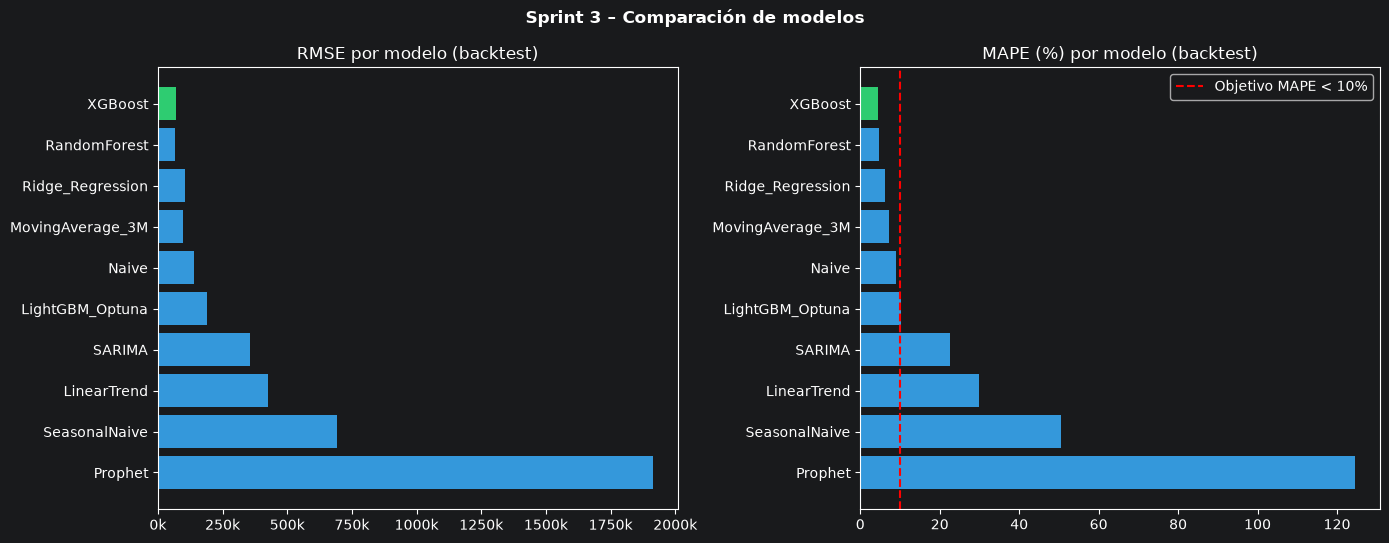

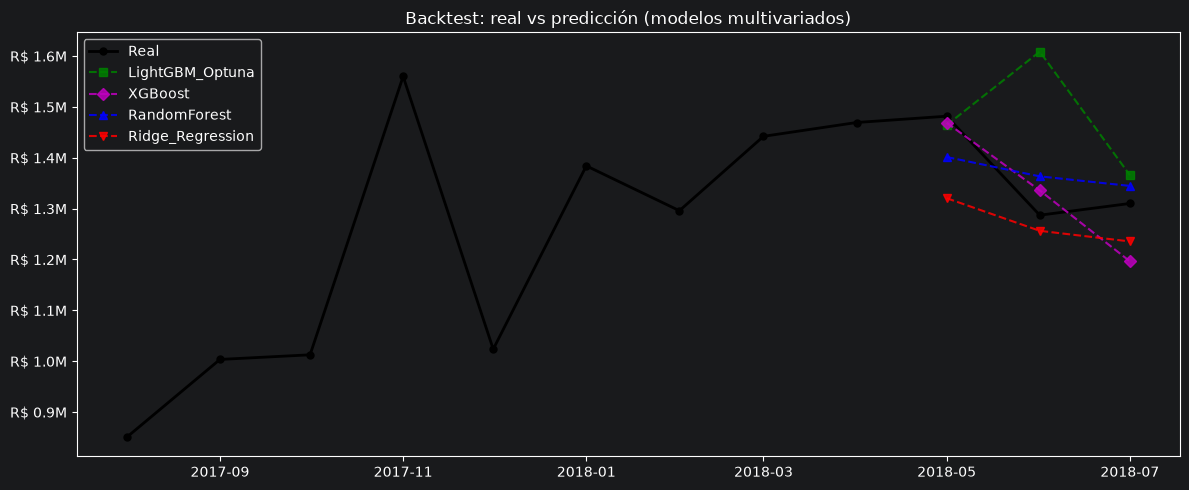

In [9]:
# ── Gráficos de rendimiento (entregable Sprint 3)
os.makedirs('reports', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in comparison['model']]

axes[0].barh(comparison['model'], comparison['rmse'], color=colors)
axes[0].set_title('RMSE por modelo (backtest)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
axes[0].invert_yaxis()

axes[1].barh(comparison['model'], comparison['mape'], color=colors)
axes[1].axvline(10, color='red', ls='--', lw=1.5, label='Objetivo MAPE < 10%')
axes[1].set_title('MAPE (%) por modelo (backtest)')
axes[1].invert_yaxis()
axes[1].legend()

plt.suptitle('Sprint 3 – Comparación de modelos', fontweight='bold')
plt.tight_layout()
plt.savefig('reports/sprint3_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Real vs predicción en el backtest (modelos multivariados)
fig, ax = plt.subplots(figsize=(12, 5))
hist = all_data.tail(12)
ax.plot(hist['ds'], hist[target], 'k-o', label='Real', lw=2, ms=5)
styles = {'LightGBM_Optuna': 'g--s', 'XGBoost': 'm--D',
          'RandomForest': 'b--^', 'Ridge_Regression': 'r--v'}
for name, style in styles.items():
    ax.plot(test_data['ds'][:n_test], preds[name], style, label=name, alpha=0.85)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.set_title('Backtest: real vs predicción (modelos multivariados)')
ax.legend()
plt.tight_layout()
plt.savefig('reports/sprint3_backtest_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## Paso 4 – Modelo final: reentrenamiento con todo el histórico + forecast

El modelo final se reentrena con **todos los meses disponibles** (práctica estándar una vez validado en backtest) y se genera el forecast de los próximos 3 meses con **intervalos de confianza basados en residuos** (`predict_with_intervals`, que reemplaza el supuesto fijo de ±15% usado provisionalmente en el Sprint 2).

Entrenando modelo final con todo el histórico…


2026-06-12 22:54:54.761 | INFO     | src.models.forecaster:fit:87 - LightGBM entrenado (3 horizontes)
2026-06-12 22:54:54.762 | INFO     | src.models.trainer:train_final_model:158 - Modelo final entrenado con mejores hiperparámetros



🔮 FORECAST – próximos 3 meses (IC 95%):
  Aug 2018: R$ 1,305,752.60   [R$ 1,151,797.43 – R$ 1,459,707.78]
  Sep 2018: R$ 1,291,812.23   [R$ 1,017,427.57 – R$ 1,566,196.89]
  Oct 2018: R$ 1,416,835.27   [R$ 1,090,412.70 – R$ 1,743,257.83]


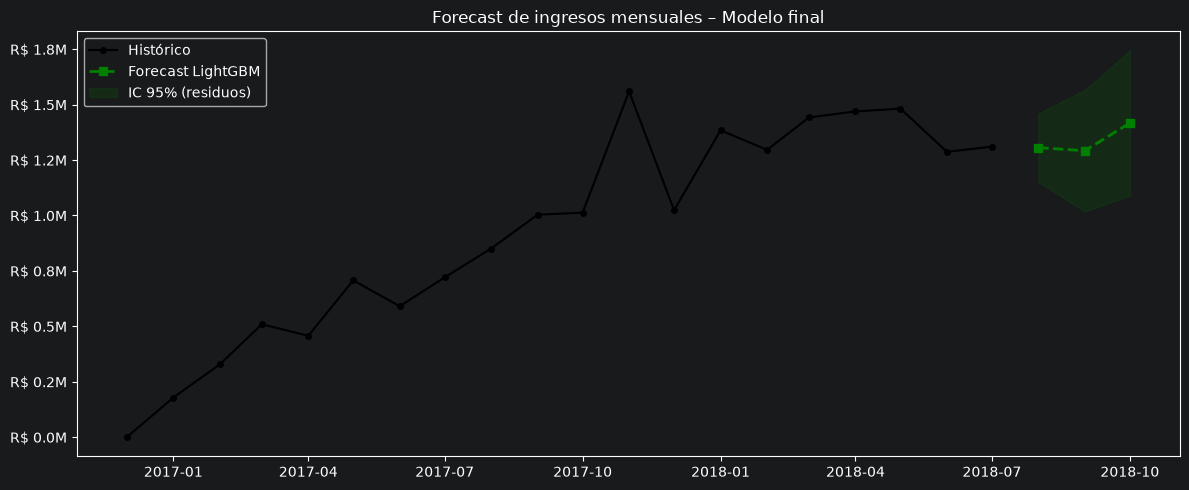

In [10]:
print('Entrenando modelo final con todo el histórico…')
final_forecaster = train_final_model(all_data[selected_features], all_data[target],
                                     best_params, selected_features, horizon=horizon)

# Forecast con IC 95% basado en residuos in-sample (inflados x1.5 por conservadurismo)
forecast_ci = final_forecaster.predict_with_intervals(all_data[selected_features].tail(1))
last_date   = all_data['ds'].max()
forecast_ci['ds'] = [last_date + pd.DateOffset(months=int(h)) for h in forecast_ci['horizon']]

print('\n🔮 FORECAST – próximos 3 meses (IC 95%):')
print('='*70)
for _, r in forecast_ci.iterrows():
    print(f"  {r['ds']:%b %Y}: R$ {r['yhat']:>12,.2f}   "
          f"[R$ {r['yhat_lower']:>12,.2f} – R$ {r['yhat_upper']:>12,.2f}]")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(all_data['ds'], all_data[target], 'k-o', label='Histórico', lw=1.5, ms=4)
ax.plot(forecast_ci['ds'], forecast_ci['yhat'], 'g--s', label='Forecast LightGBM', lw=2)
ax.fill_between(forecast_ci['ds'], forecast_ci['yhat_lower'], forecast_ci['yhat_upper'],
                color='green', alpha=0.15, label='IC 95% (residuos)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R$ {x/1e6:.1f}M'))
ax.set_title('Forecast de ingresos mensuales – Modelo final')
ax.legend()
plt.tight_layout()
plt.savefig('reports/sprint3_final_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

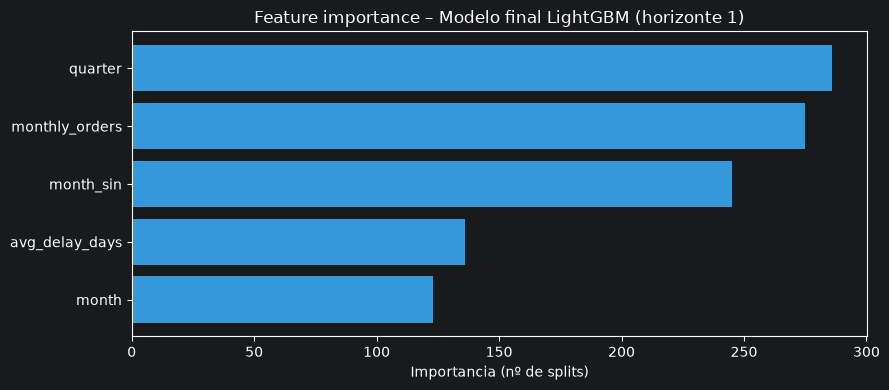

,feature,importance
4,quarter,286
0,monthly_orders,275
2,month_sin,245
1,avg_delay_days,136
3,month,123


In [11]:
# ── Feature importance del modelo final (entregable Sprint 3)
fi = final_forecaster.feature_importance()

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(fi['feature'], fi['importance'], color='#3498db')
ax.invert_yaxis()
ax.set_title('Feature importance – Modelo final LightGBM (horizonte 1)')
ax.set_xlabel('Importancia (nº de splits)')
plt.tight_layout()
plt.savefig('reports/sprint3_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
fi

### Paso 4b – Salida de la Selección de Variables (tabla del flujo de ejemplo)

El flujo de ejemplo exige como salida una **tabla por variable** (exportable a CSV) con:

`Nro | Dominio | Variable | flagSelected | importancia_seleccion | importancia_modelo_final`

Adaptación: el *Dominio* se infiere del prefijo de la variable (Calendario, Historia del target, Órdenes, Entregas…), `importancia_seleccion` es el score de información mutua normalizado a 100% entre seleccionadas, e `importancia_modelo_final` es la importancia del LightGBM final normalizada a 100%.

In [12]:
from src.features.selection_table import build_selection_table, export_selection_table

sel_table = build_selection_table(
    all_columns=list(monthly_clean.columns),
    selected_features=selected_features,
    steps_report=selection_result['steps_report'],
    final_importance=final_forecaster.feature_importance(),
    target_col=target,
)
csv_path = export_selection_table(sel_table, 'reports/seleccion_variables.csv')

print(f"📄 Tabla exportada: {csv_path} ({len(sel_table)} variables)\n")
print('Variables SELECCIONADAS (flagSelected = 1):')
print(sel_table[sel_table['flagSelected'] == 1].to_string(index=False))
print('\nResumen por dominio:')
print(sel_table.groupby('Dominio')['flagSelected'].agg(['count', 'sum'])
      .rename(columns={'count': 'total', 'sum': 'seleccionadas'}).to_string())
sel_table.head(15)

2026-06-12 22:57:12.805 | INFO     | src.features.selection_table:build_selection_table:124 - Tabla de selección generada: 44 variables, 5 seleccionadas (importancia_seleccion suma 100.0%)
2026-06-12 22:57:12.812 | INFO     | src.features.selection_table:export_selection_table:135 - Tabla de selección exportada: reports/seleccion_variables.csv


📄 Tabla exportada: reports/seleccion_variables.csv (44 variables)

Variables SELECCIONADAS (flagSelected = 1):
 Nro                     Dominio       Variable  flagSelected  importancia_seleccion  importancia_modelo_final
   4                     Órdenes monthly_orders             1                  50.70                     25.82
  11                    Entregas avg_delay_days             1                  13.62                     12.77
  39 Calendario / Estacionalidad          month             1                  18.61                     11.55
  40 Calendario / Estacionalidad        quarter             1                   5.73                     26.85
  41 Calendario / Estacionalidad      month_sin             1                  11.34                     23.00

Resumen por dominio:
                             total  seleccionadas
Dominio                                          
Calendario / Estacionalidad      8              3
Clientes                         1              0
D

,Nro,Dominio,Variable,flagSelected,importancia_seleccion,importancia_modelo_final
0,1,Calendario / Estacionalidad,year_month,0,0.00,0.00
1,2,Target,monthly_revenue,0,0.00,0.00
2,3,Calendario / Estacionalidad,ds,0,0.00,0.00
3,4,Órdenes,monthly_orders,1,50.70,25.82
4,5,Clientes,monthly_customers,0,0.00,0.00
5,6,Órdenes,monthly_items,0,0.00,0.00
6,7,Ticket / Precio,avg_ticket,0,0.00,0.00
7,8,Ticket / Precio,median_ticket,0,0.00,0.00
8,9,Satisfacción,avg_review_score,0,0.00,0.00
9,10,Entregas,avg_delivery_days,0,0.00,0.00


## Paso 5 – Exportación del modelo final (.pkl)

Se exportan dos artefactos:

- `lgbm_forecaster.pkl` y `cleaning_pipeline.pkl`: artefactos **operativos** que consume `PredictPipeline` en la ejecución mensual.
- `final_model.pkl`: **bundle con metadata** de trazabilidad (`final_model['metadata']`, el equivalente práctico del `final_model.__dict__` del flujo de ejemplo) — features, hiperparámetros, métricas del backtest, **gap de sobreajuste**, costo de selección, rango de entrenamiento y **versiones exactas de librerías**.

In [13]:
import platform, json
from datetime import datetime
from src.utils.helpers import save_model

# 1) Artefactos operativos (compatibles con PredictPipeline)
save_model(final_forecaster, 'lgbm_forecaster')
save_model(cleaning_pipeline, 'cleaning_pipeline')

# 2) Bundle final con metadata de trazabilidad
m   = comparison[comparison['model'] == 'LightGBM_Optuna'].iloc[0]
g   = gap_df[gap_df['model'] == 'LightGBM_Optuna'].iloc[0]
challenger = comparison[comparison['model'].isin(['RandomForest', 'XGBoost', 'MovingAverage_3M'])]
metadata = {
    'model_type':        'LightGBMForecaster (direct multi-step, 3 horizontes)',
    'trained_at':        datetime.now().isoformat(timespec='seconds'),
    'training_range':    f"{all_data['ds'].min():%Y-%m} → {all_data['ds'].max():%Y-%m}",
    'n_train_months':    int(len(all_data)),
    'selected_features': selected_features,
    'best_params':       best_params,
    'metrics_backtest':  {k: float(m[k]) for k in ['rmse', 'mae', 'mape', 'smape']},
    'overfit_gap': {
        'rmse_train':     float(g['rmse_train']),
        'rmse_backtest':  float(g['rmse_backtest']),
        'gap_rmse_ratio': float(g['gap_rmse_ratio']),
    },
    'challengers_backtest': {
        r['model']: round(float(r['mape']), 2) for _, r in challenger.iterrows()
    },
    'selection_cost':    cost_df.to_dict('records'),
    'versions': {
        'python':       platform.python_version(),
        'scikit-learn': sklearn.__version__,
        'lightgbm':     lightgbm.__version__,
        'xgboost':      xgboost.__version__,
        'optuna':       optuna.__version__,
        'pandas':       pd.__version__,
        'numpy':        np.__version__,
    },
}
save_model({'forecaster': final_forecaster, 'metadata': metadata}, 'final_model')

print('\n✅ Artefactos guardados en data/models/:')
print('   - lgbm_forecaster.pkl   (operativo – PredictPipeline)')
print('   - cleaning_pipeline.pkl (operativo – PredictPipeline)')
print('   - final_model.pkl       (modelo + metadata ≈ final_model.__dict__)')
print('\n📋 Metadata del modelo final:')
print(json.dumps(metadata, indent=2, ensure_ascii=False, default=str))

2026-06-12 22:57:49.621 | INFO     | src.utils.helpers:save_model:52 - Modelo guardado: D:\2026\maestria\mod13\ProyectoG10\data\models\lgbm_forecaster.pkl
2026-06-12 22:57:49.649 | INFO     | src.utils.helpers:save_model:52 - Modelo guardado: D:\2026\maestria\mod13\ProyectoG10\data\models\cleaning_pipeline.pkl
2026-06-12 22:57:49.717 | INFO     | src.utils.helpers:save_model:52 - Modelo guardado: D:\2026\maestria\mod13\ProyectoG10\data\models\final_model.pkl



✅ Artefactos guardados en data/models/:
   - lgbm_forecaster.pkl   (operativo – PredictPipeline)
   - cleaning_pipeline.pkl (operativo – PredictPipeline)
   - final_model.pkl       (modelo + metadata ≈ final_model.__dict__)

📋 Metadata del modelo final:
{
  "model_type": "LightGBMForecaster (direct multi-step, 3 horizontes)",
  "trained_at": "2026-06-12T22:57:49",
  "training_range": "2016-12 → 2018-07",
  "n_train_months": 20,
  "selected_features": [
    "monthly_orders",
    "avg_delay_days",
    "month_sin",
    "month",
    "quarter"
  ],
  "best_params": {
    "n_estimators": 638,
    "learning_rate": 0.0835361075531176,
    "num_leaves": 19,
    "max_depth": 4,
    "min_child_samples": 6,
    "subsample": 0.7301321323053057,
    "colsample_bytree": 0.7554709158757928,
    "reg_alpha": 0.2713490317738959,
    "reg_lambda": 0.8287375091519293
  },
  "metrics_backtest": {
    "rmse": 188709.76062561065,
    "mae": 131616.38347241064,
    "mape": 10.142280593949494,
    "smape": 9.

## Justificación del modelo elegido

**Lectura honesta de los resultados (backtest de 3 meses):**

- **XGBoost** logra el mejor MAPE (~4.5%) pero con un gap train→backtest extremo (su error crece ~180x al salir del train: con 17 meses memoriza el train casi a la perfección). Según el criterio del propio flujo de ejemplo — *reducir la distancia train vs backtest* — queda **descartado** pese a su MAPE: no hay evidencia de que generalice.
- **Random Forest** combina el segundo mejor MAPE (~4.7%) con el mejor gap (≈1): el candidato con mejor equilibrio precisión–generalización en esta ventana.
- **LightGBM (Optuna)** queda en ~10.1% con gap moderado (≈1.8). **Ridge** ~6.3% (gap ≈1.5). Los baselines simples (MA-3M ~7.1%) siguen siendo competitivos, algo esperable con ~20 meses de historia.
- Prophet y SARIMA colapsan (>20% MAPE): una serie tan corta no alcanza para estimar bien estacionalidad anual univariada.

**Decisión: LightGBM se mantiene como champion operativo de esta iteración; Random Forest queda como challenger principal.** Justificación:

1. **n=3 no es concluyente:** con solo 3 puntos de backtest, la diferencia RF vs LightGBM puede ser azar muestral. Cambiar el modelo de producción por 3 observaciones sería sobre-reaccionar al ruido (el mismo error que el gap intenta evitar).
2. **Requisitos operativos del proyecto:** LightGBM es el único candidato con actualización incremental (`update()` con `init_model`, requisito del Sprint 2), espacio de búsqueda Optuna ya integrado e intervalos de predicción por residuos. RF/XGBoost requieren reentrenar desde cero cada mes.
3. **Regla de promoción explícita (champion–challenger):** cada mes se compara el MAPE realizado de LightGBM vs Random Forest (challenger multivariado) y MA-3M (challenger estadístico), registrados en `metadata['challengers_backtest']`. **Si un challenger gana 2 meses consecutivos con datos reales, se promueve a champion.** Así la decisión se corrige sola con evidencia, no con ruido.

**Nota sobre la evaluación:** a diferencia de la versión preliminar del Sprint 2 (que evaluaba usando features del propio período de test), aquí la predicción multi-step se hace **solo con información disponible al final de train** — sin fuga de información. Estos son los números realistas de producción.

## Pipeline de retraining mensual (documentación operativa)

Cada mes, al llegar los nuevos CSVs de Olist:

```text
1. Colocar los CSVs actualizados en data/raw/
2. Reentrenamiento completo (recomendado 1 vez por trimestre):
       from src.pipeline.train_pipeline import TrainPipeline
       TrainPipeline().run(tune=True)          # re-optimiza con Optuna
3. Actualización incremental (mensual, barata):
       pipe = TrainPipeline(); pipe.run(tune=False)
       pipe.step_incremental_update(new_month_df)   # warm-start +20 árboles
4. Predicción del mes siguiente:
       from src.pipeline.predict_pipeline import PredictPipeline
       PredictPipeline().run()                 # carga lgbm_forecaster.pkl + cleaning_pipeline.pkl
5. Monitoreo champion-challenger:
       - comparar MAPE realizado de LightGBM vs RandomForest y MA-3M
       - monitorear gap train→backtest del retraining (metadata['overfit_gap'])
       - challenger gana 2 meses seguidos  → promover a champion
       - MAPE > 10% durante 2 meses seguidos → reentrenamiento completo con tuning
```

## Conclusiones del Sprint 3

- Se compararon **9 modelos** (4 baselines + RF + Ridge + XGBoost + LightGBM + Prophet + SARIMA) bajo el mismo protocolo de backtest sin fuga de información, cubriendo los candidatos del flujo de ejemplo (árboles, regresión, XGBoost).
- La **salida de la selección de variables** queda trazable variable a variable (`reports/seleccion_variables.csv` con flagSelected + importancias) y se cuantificó el **costo de la selección** (equivalente al "60→30: Gini 50→47").
- El **gap train→backtest** operacionaliza el control de sobreajuste del flujo de ejemplo: descartó a XGBoost (mejor MAPE pero gap ~180x) y reveló a Random Forest como challenger serio — exactamente el tipo de decisión que esta métrica existe para informar.
- La hiperparametrización con **Optuna + CV temporal** (30 trials) define el modelo final de forma reproducible.
- El modelo final se exporta como **`final_model.pkl`** con metadata completa (≈ `final_model.__dict__`), incluyendo métricas de challengers para el monitoreo mensual, y queda listo para `PredictPipeline`.
- Los intervalos del forecast se basan en **residuos del modelo** (IC 95%), reemplazando el supuesto fijo ±15%.